# Ensemble forecasting with NeuralGCM-ENS (stochastic 1.4°)

The **stochastic 1.4° model** carries learned Gaussian random fields
(ten of them, with learned correlation times and lengths) that perturb
the physics at every step. Different integer seeds give different
ensemble members.

This notebook runs a small 4-member ensemble with `encode_ensemble`,
which **batches the members through a single model call** (one leading
*member* axis instead of a Python loop), and looks at the ensemble mean
and spread.

Needs network access (checkpoint + ERA5, anonymous GCS) and a GPU.


In [2]:
import pathlib

import numpy as np
import torch
import xarray

from dinosaur_torch import horizontal_interpolation
from dinosaur_torch import xarray_utils
import neuralgcm_torch as neuralgcm

device = 'cuda' if torch.cuda.is_available() else 'cpu'

## Load the model

In [3]:
from neuralgcm_torch import pretrained

# Fetched from the Hugging Face Hub on first use (cached), or reused from
# a local checkpoints/ directory if present.
converted_path = pretrained.fetch_checkpoint('stochastic_1_4_deg', local_root='checkpoints')
model = neuralgcm.PressureLevelModel.from_checkpoint(converted_path, device=device)
(model.longitudes.size, model.latitudes.size,
 sum(p.numel() for p in model.model.parameters()))

(256, 128, 11519823)

## Load and regrid ERA5

In [4]:
era5_path = 'gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3'
full_era5 = xarray.open_zarr(
    era5_path, chunks=None, storage_options=dict(token='anon')
)

demo_start_time = '2020-02-14'
demo_end_time = '2020-02-18'
data_inner_steps = 24  # process every 24th hour

sliced_era5 = (
    full_era5
    [model.input_variables + model.forcing_variables]
    .pipe(
        xarray_utils.selective_temporal_shift,
        variables=model.forcing_variables,
        time_shift='24 hours',
    )
    .sel(time=slice(demo_start_time, demo_end_time, data_inner_steps))
    .compute()
)

era5_grid = xarray_utils.grid_spec_from_dataset(full_era5)
regridder = horizontal_interpolation.ConservativeRegridder(
    era5_grid, model.data_grid, skipna=True, device=device
)
eval_era5 = xarray_utils.regrid_horizontal(sliced_era5, regridder)
eval_era5 = xarray_utils.fill_nan_with_nearest(eval_era5)

## Make an ensemble forecast

`encode_ensemble` encodes one member per seed and stacks them along a
leading *member* axis; `unroll` then advances every member through a
single batched model call (the dynamical core and physics network run as
batched tensor ops), and the decoded outputs carry a `member` dimension
after `time`. Each member draws exactly the noise its sequential
`encode(rng=seed)` run would, so batching changes the speed, not the
physics.


In [5]:
inner_steps = 24  # save model outputs once every 24 hours
outer_steps = 4 * 24 // inner_steps  # total of 4 days
timedelta = np.timedelta64(1, 'h') * inner_steps
times = np.arange(outer_steps) * inner_steps  # time axis in hours
n_members = 4

inputs = model.inputs_from_xarray(eval_era5.isel(time=0))
input_forcings = model.forcings_from_xarray(eval_era5.isel(time=0))
all_forcings = model.forcings_from_xarray(eval_era5.head(time=1))

# All members share one batched unroll. `members=` tags the member axis
# when packaging the outputs to xarray.
state = model.encode_ensemble(inputs, input_forcings, rngs=range(n_members))
_, predictions = model.unroll(
    state, all_forcings, steps=outer_steps, timedelta=timedelta,
    start_with_input=True,
)
ensemble_ds = model.data_to_xarray(
    predictions, times=times, members=np.arange(n_members)
)
ensemble_ds

<xarray.Dataset> Size: 543MB
Dimensions:                              (time: 4, member: 4, level: 37,
                                          longitude: 256, latitude: 128)
Coordinates:
  * time                                 (time) int64 32B 0 24 48 72
  * member                               (member) int64 32B 0 1 2 3
  * level                                (level) float64 296B 1.0 2.0 ... 1e+03
  * longitude                            (longitude) float64 2kB 0.0 ... 358.6
  * latitude                             (latitude) float64 1kB -88.93 ... 88.93
Data variables:
    u_component_of_wind                  (time, member, level, longitude, latitude) float32 78MB ...
    v_component_of_wind                  (time, member, level, longitude, latitude) float32 78MB ...
    temperature                          (time, member, level, longitude, latitude) float32 78MB ...
    geopotential                         (time, member, level, longitude, latitude) float32 78MB ...
    specific_humidity                    (time, member, level, longitude, latitude) float32 78MB ...
    specific_cloud_ice_water_content     (time, member, level, longitude, latitude) float32 78MB ...
    specific_cloud_liquid_water_content  (time, member, level, longitude, latitude) float32 78MB ...

### Batched members vs. an explicit loop

The same forecast as a per-member loop, for comparison. Batching is
faster (the members share each kernel launch) and computes the same
thing: the per-member noise draws are identical, so the loop-vs-batched
difference for a given member starts at floating-point round-off (`+0h`
below) and is then amplified by the chaotic dynamics, growing with lead
time at the same rate as the deliberate seed-to-seed ensemble spread.
Individual long-range trajectories are therefore not bitwise reproducible
across the two code paths (no chaotic model's are), but the ensemble
*statistics* — the mean skill and spread below — are. A single member can
be pulled back out of a batched state with
`neuralgcm.ensembles.member_state(state, i)`.


In [6]:
import time

def timed(label, fn):
  if device == 'cuda':
    torch.cuda.synchronize()
  t0 = time.perf_counter()
  out = fn()
  if device == 'cuda':
    torch.cuda.synchronize()
  print(f'{label}: {time.perf_counter() - t0:5.1f}s')
  return out

def member_loop():
  members = []
  for seed in range(n_members):
    s = model.encode(inputs, input_forcings, rng=seed)
    _, preds = model.unroll(
        s, all_forcings, steps=outer_steps, timedelta=timedelta,
        start_with_input=True,
    )
    members.append(model.data_to_xarray(preds, times=times))
  return xarray.concat(members, dim='member').assign_coords(
      member=np.arange(n_members))

def batched():
  s = model.encode_ensemble(inputs, input_forcings, rngs=range(n_members))
  _, preds = model.unroll(
      s, all_forcings, steps=outer_steps, timedelta=timedelta,
      start_with_input=True,
  )
  return model.data_to_xarray(
      preds, times=times, members=np.arange(n_members))

loop_ds = timed(f'{n_members}-member loop   ', member_loop)
batched_ds = timed(f'{n_members}-member batched', batched)

# Per member the difference grows from round-off with lead time (not a
# constant offset), tracking the chaotic ensemble spread itself.
for t in times:
  delta = abs(batched_ds.temperature.sel(time=t)
              - loop_ds.temperature.sel(time=t)).max()
  spread = ensemble_ds.temperature.sel(time=t).std('member').max()
  print(f'  +{t:>2}h: max|T_batched - T_loop| = {float(delta):.1e} K'
        f'   (max ensemble spread {float(spread):.2f} K)')

4-member loop   : 148.8s


4-member batched:  67.8s
  + 0h: max|T_batched - T_loop| = 1.5e-03 K   (max ensemble spread 7.26 K)
  +24h: max|T_batched - T_loop| = 4.7e-01 K   (max ensemble spread 4.72 K)
  +48h: max|T_batched - T_loop| = 8.1e-01 K   (max ensemble spread 6.28 K)
  +72h: max|T_batched - T_loop| = 5.2e-01 K   (max ensemble spread 8.58 K)


## Skill of the ensemble mean

The ensemble mean is typically more skillful than individual members
(here measured by day-4 T850 RMSE against ERA5). Computed for both the
batched and the looped ensembles: they are statistically equivalent — the
per-member trajectories differ only by the chaotic growth of
floating-point round-off, so the skill matches to a few hundredths of a
kelvin.

In [7]:
target_trajectory = model.inputs_from_xarray(
    eval_era5
    .thin(time=(inner_steps // data_inner_steps))
    .isel(time=slice(outer_steps))
)
target_ds = model.data_to_xarray(target_trajectory, times=times)

w = np.cos(np.deg2rad(target_ds.latitude))
t850_target = target_ds.sel(level=850).temperature.isel(time=-1)

def rmse(da):
  return float(np.sqrt(((da - t850_target) ** 2).weighted(w).mean()))

def member_and_mean_rmse(ds):
  t850 = ds.sel(level=850).temperature.isel(time=-1)
  members = [rmse(t850.sel(member=m)) for m in range(n_members)]
  return np.round(members, 2), rmse(t850.mean('member'))

batched_members, batched_mean = member_and_mean_rmse(batched_ds)
loop_members, loop_mean = member_and_mean_rmse(loop_ds)
persistence = rmse(target_ds.sel(level=850).temperature.isel(time=0))

print('day-4 T850 RMSE (K):')
print(f'  batched: members {batched_members}, ensemble mean {batched_mean:.2f}')
print(f'  loop:    members {loop_members}, ensemble mean {loop_mean:.2f}')
print(f'  persistence {persistence:.2f}')

day-4 T850 RMSE (K):
  batched: members [1.44 1.49 1.41 1.42], ensemble mean 1.08
  loop:    members [1.44 1.49 1.41 1.42], ensemble mean 1.08
  persistence 4.24


## Ensemble spread

The spread (standard deviation across members) grows with lead time and
highlights the flow-dependent uncertainty:

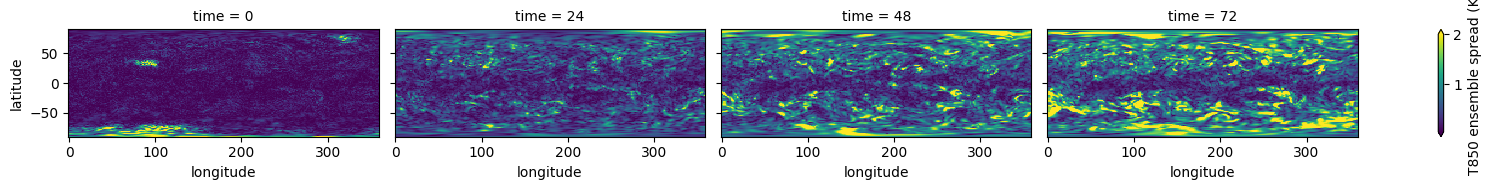

In [8]:
ensemble_ds.sel(level=850).temperature.std('member').plot(
    x='longitude', y='latitude', col='time', robust=True, aspect=2, size=2,
    cbar_kwargs={'label': 'T850 ensemble spread (K)'},
);